1. Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'iframe'

df = pd.read_csv('tracks.csv')

# Базовая очистка от пропусков
df = df.dropna(subset=['popularity', 'danceability', 'energy', 'duration_ms'])

# Извлекаем год из release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Отфильтруем разумный диапазон годов (например, с 1990 по 2023)
df = df[(df['year'] >= 1990) & (df['year'] <= 2023)]

print(f"Данные загружены. Треков: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")

Данные загружены. Треков: 279057
Колонки: ['id', 'name', 'popularity', 'duration_ms', 'explicit', 'artists', 'id_artists', 'release_date', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'year']


Распределение популярности (popularity)

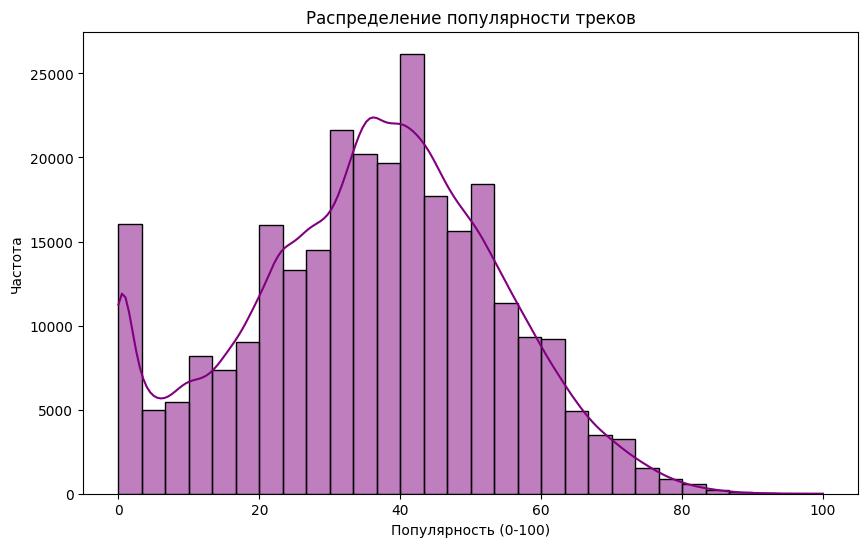

Средняя популярность: 35.92
Медианная популярность: 37.00
Вывод: популярность скошена ВЛЕВО (больше непопулярных треков)


In [2]:
plt.figure(figsize=(10,6))
sns.histplot(df['popularity'], bins=30, kde=True, color='purple')
plt.title('Распределение популярности треков')
plt.xlabel('Популярность (0-100)')
plt.ylabel('Частота')
plt.show()

# Распределение скошено вправо или влево?
print(f"Средняя популярность: {df['popularity'].mean():.2f}")
print(f"Медианная популярность: {df['popularity'].median():.2f}")
# Если среднее < медианы, то скошено влево, если среднее > медианы, то скошено вправо.
if df['popularity'].mean() < df['popularity'].median():
    print("Вывод: популярность скошена ВЛЕВО (больше непопулярных треков)")
else:
    print("Вывод: популярность скошена ВПРАВО (больше популярных треков)")

Влияние explicit-контента на популярность (boxplot)

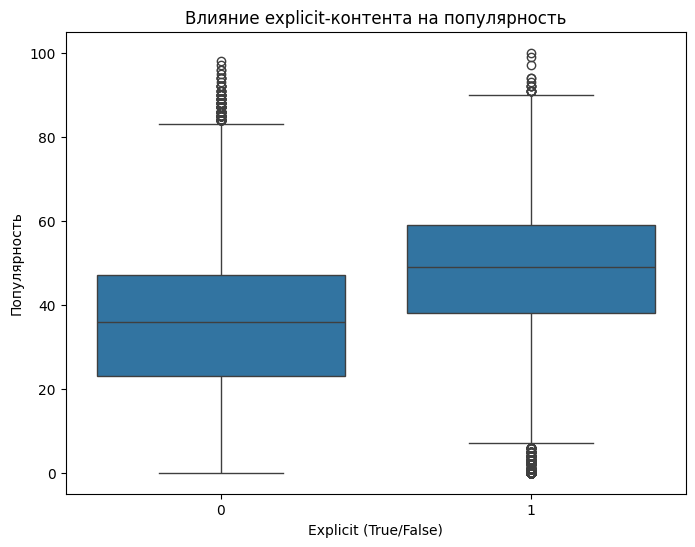

Средняя популярность explicit треков: 47.31
Средняя популярность non-explicit треков: 34.90


In [3]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='explicit', y='popularity')
plt.title('Влияние explicit-контента на популярность')
plt.xlabel('Explicit (True/False)')
plt.ylabel('Популярность')
plt.show()

# Статистическая проверка.
explicit_true = df[df['explicit'] == True]['popularity']
explicit_false = df[df['explicit'] == False]['popularity']
print(f"Средняя популярность explicit треков: {explicit_true.mean():.2f}")
print(f"Средняя популярность non-explicit треков: {explicit_false.mean():.2f}")

Топ-10 исполнителей по количеству треков (горизонтальная диаграмма)

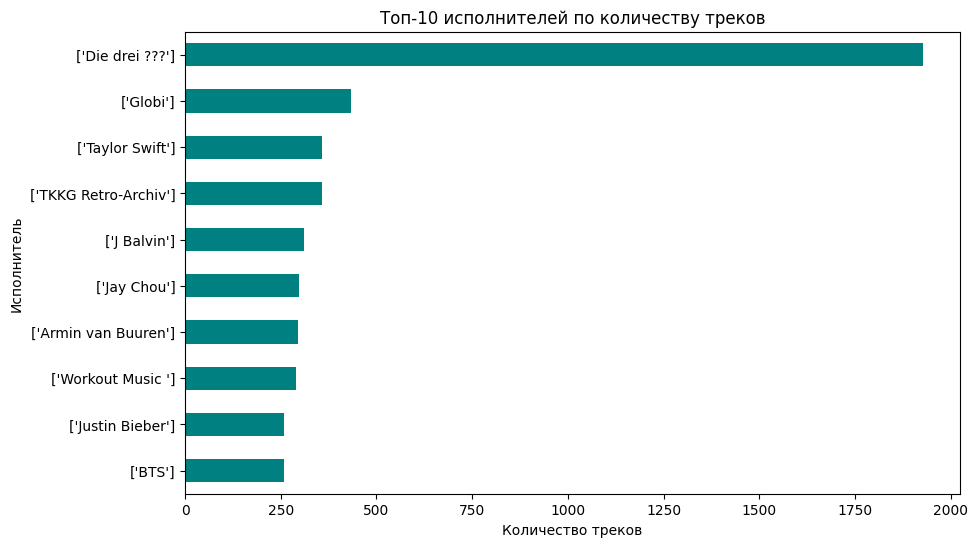

In [4]:
top_artists = df['artists'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_artists.plot(kind='barh', color='teal')
plt.title('Топ-10 исполнителей по количеству треков')
plt.xlabel('Количество треков')
plt.ylabel('Исполнитель')
plt.gca().invert_yaxis()  # чтобы первый был сверху
plt.show()

Распределение длительности треков (гистограмма)

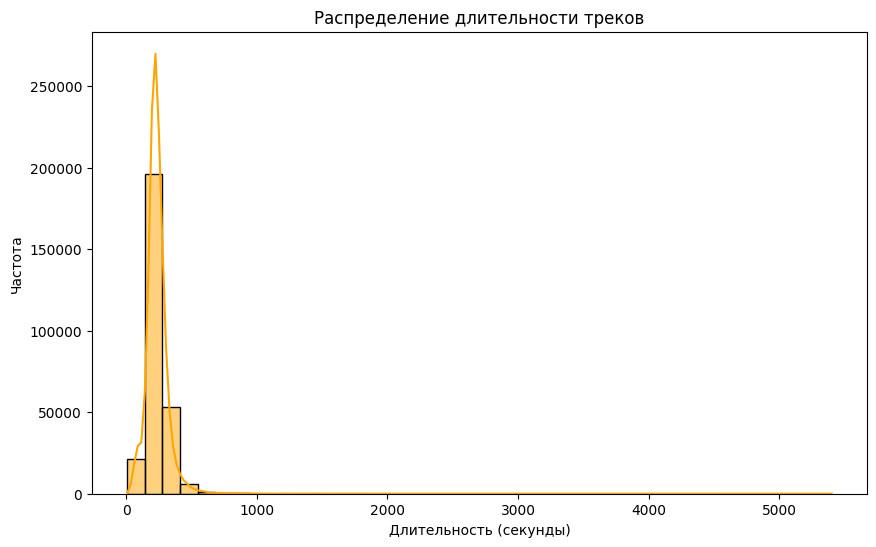

In [5]:
plt.figure(figsize=(10,6))
sns.histplot(df['duration_ms'] / 1000, bins=40, kde=True, color='orange')
plt.title('Распределение длительности треков')
plt.xlabel('Длительность (секунды)')
plt.ylabel('Частота')
plt.show()

Матрица корреляции для числовых колонок

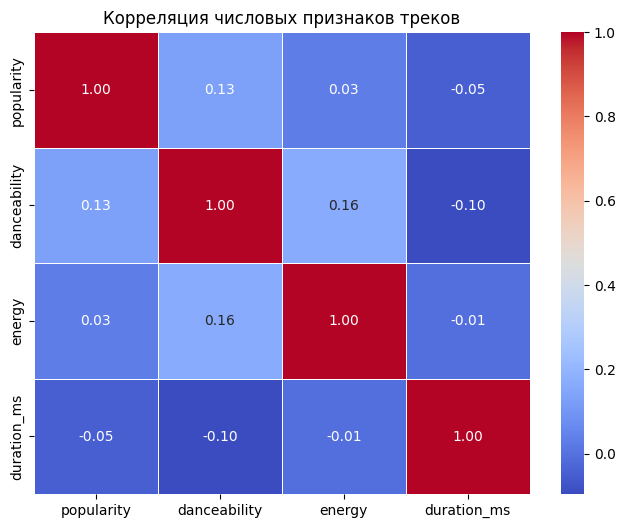

Сильнее всего коррелирует с популярностью: danceability (r = 0.129)


In [6]:
numeric_cols = ['popularity', 'danceability', 'energy', 'duration_ms']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляция числовых признаков треков')
plt.show()

# Какая характеристика сильнее всего коррелирует с популярностью?
corr_with_popularity = corr_matrix['popularity'].drop('popularity').abs().sort_values(ascending=False)
print(f"Сильнее всего коррелирует с популярностью: {corr_with_popularity.index[0]} (r = {corr_with_popularity.values[0]:.3f})")

Анализ "энергии" топ-5 исполнителей

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_20784\1750930581.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top5, x='artists', y='energy', palette='Set2')


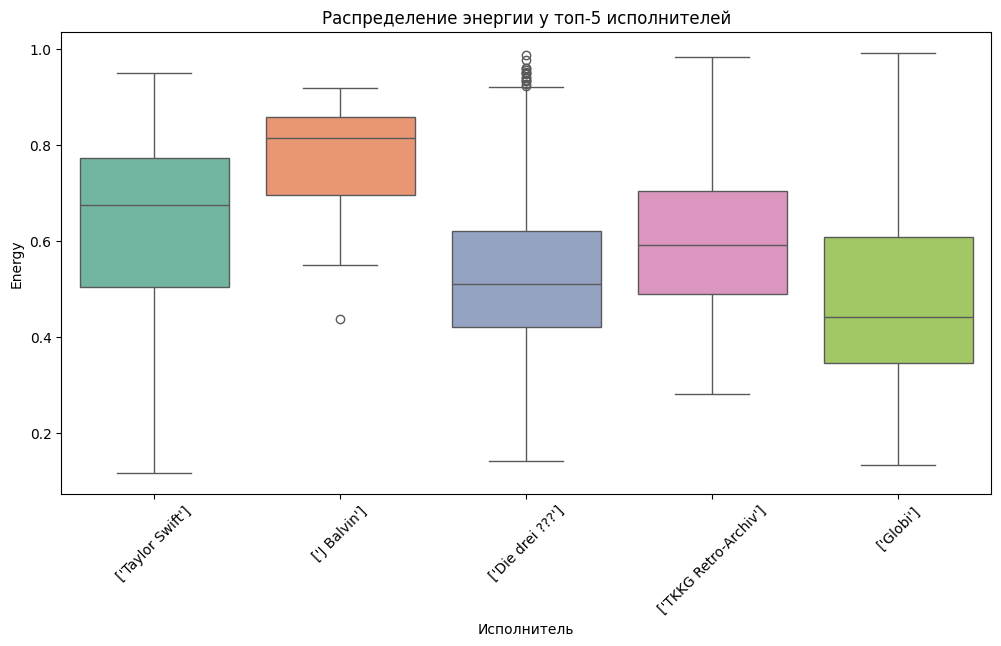

['Die drei ???']: средняя energy = 0.52, std = 0.15
['Globi']: средняя energy = 0.48, std = 0.19
['Taylor Swift']: средняя energy = 0.64, std = 0.17
['TKKG Retro-Archiv']: средняя energy = 0.60, std = 0.15
['J Balvin']: средняя energy = 0.78, std = 0.10


In [7]:
# Топ-5 исполнителей по количеству треков.
top5_artists = df['artists'].value_counts().head(5).index
df_top5 = df[df['artists'].isin(top5_artists)]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top5, x='artists', y='energy', palette='Set2')
plt.title('Распределение энергии у топ-5 исполнителей')
plt.xlabel('Исполнитель')
plt.ylabel('Energy')
plt.xticks(rotation=45)
plt.show()

# У кого энергия стабильно высокая, а у кого - с большим разбросом?
for artist in top5_artists:
    data = df_top5[df_top5['artists'] == artist]['energy']
    print(f"{artist}: средняя energy = {data.mean():.2f}, std = {data.std():.2f}")

Танцевальность vs Энергия (интерактивный scatter plot)

In [8]:
# Нормализуем duration_ms для размера точек (от 10 до 40).
df['size_norm'] = 10 + (df['duration_ms'] - df['duration_ms'].min()) / (df['duration_ms'].max() - df['duration_ms'].min()) * 30

fig = px.scatter(
    df,
    x='danceability',
    y='energy',
    color='popularity',
    size='size_norm',
    hover_data=['name', 'artists', 'popularity'],
    title='Танцевальность vs Энергия',
    labels={'danceability': 'Танцевальность', 'energy': 'Энергия'},
    color_continuous_scale='Viridis'
)
fig.show()

Динамика танцевальности по годам

In [9]:
# Группируем по годам.
dance_by_year = df.groupby('year')['danceability'].mean().reset_index()

fig = px.line(
    dance_by_year,
    x='year',
    y='danceability',
    markers=True,
    title='Динамика средней танцевальности по годам (1990-2023)',
    labels={'year': 'Год', 'danceability': 'Средняя танцевальность'}
)
fig.show()

Статический дашборд (графики 1,3,5,6)

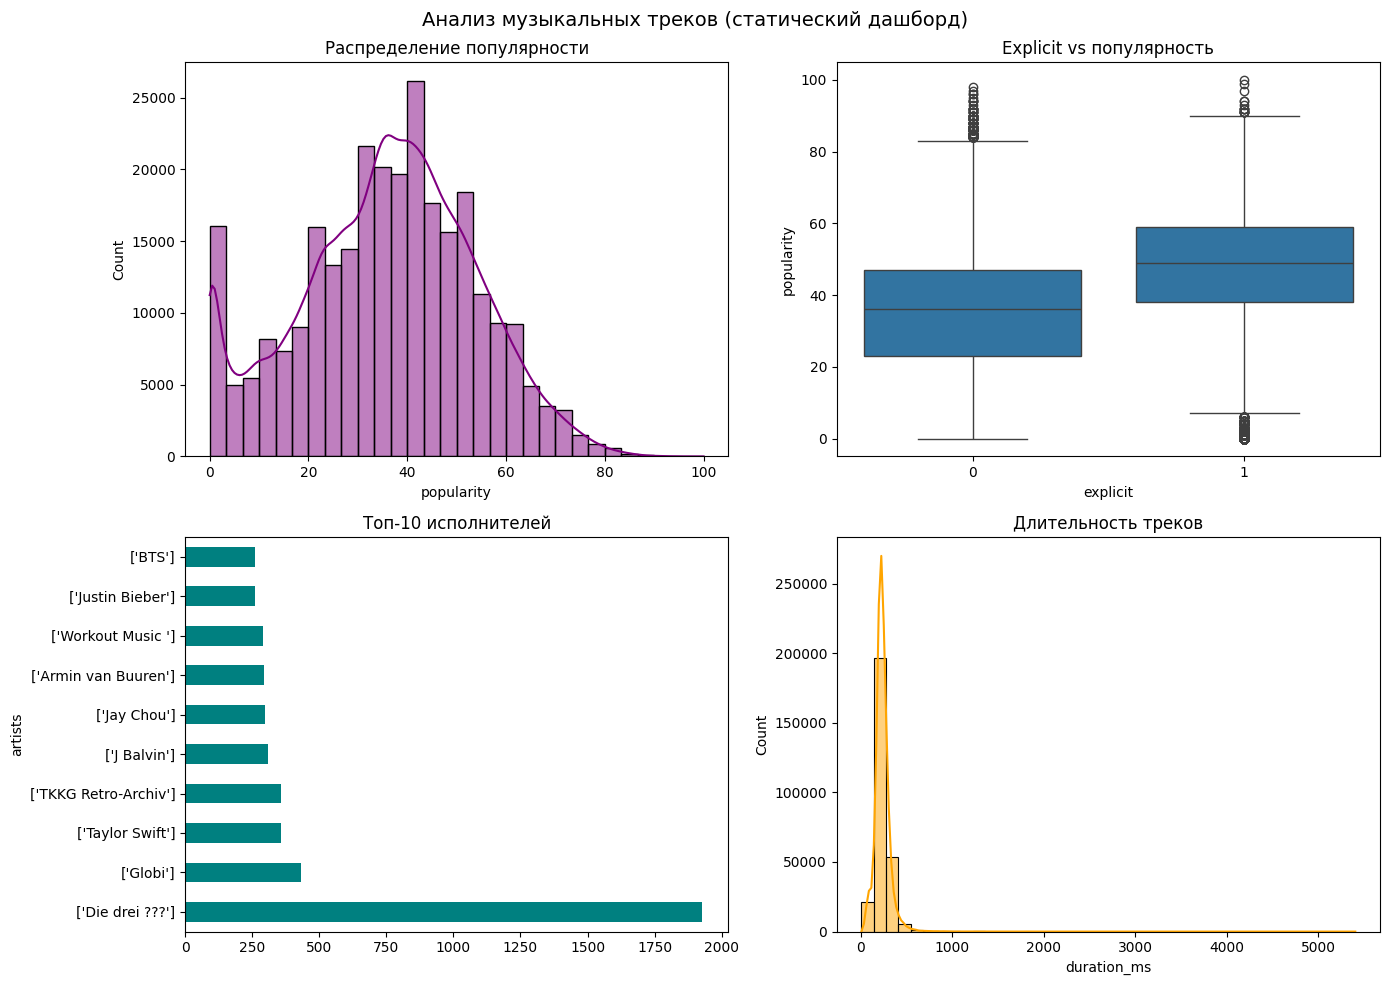

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ музыкальных треков (статический дашборд)', fontsize=14)

# Распределение популярности.
sns.histplot(df['popularity'], bins=30, kde=True, color='purple', ax=axes[0,0])
axes[0,0].set_title('Распределение популярности')

# Boxplot explicit vs popularity.
sns.boxplot(data=df, x='explicit', y='popularity', ax=axes[0,1])
axes[0,1].set_title('Explicit vs популярность')

# Топ-10 исполнителей.
df['artists'].value_counts().head(10).plot(kind='barh', color='teal', ax=axes[1,0])
axes[1,0].set_title('Топ-10 исполнителей')

# Гистограмма длительности.
sns.histplot(df['duration_ms']/1000, bins=40, kde=True, color='orange', ax=axes[1,1])
axes[1,1].set_title('Длительность треков')

plt.tight_layout()
plt.savefig('tracks_static_dashboard.png', dpi=150)
plt.show()

Интерактивный дашборд (графики 2,4,7,8)

In [ ]:
# Сохраняем каждый интерактивный график.
fig_scatter = px.scatter(df.sample(min(1000, len(df))), x='danceability', y='energy', color='popularity', 
                         hover_data=['name', 'artists'], title='Танцевальность vs Энергия')
fig_scatter.write_html('scatter_dance_energy.html')

fig_line = px.line(dance_by_year, x='year', y='danceability', markers=True, title='Динамика танцевальности')
fig_line.write_html('dance_timeline.html')

fig_corr = px.imshow(corr_matrix, text_auto=True, color_continuous_scale='RdBu', title='Корреляция признаков')
fig_corr.write_html('correlation_heatmap.html')

fig_energy = px.box(df_top5, x='artists', y='energy', color='artists', title='Energy топ-5 исполнителей')
fig_energy.write_html('energy_boxplot.html')

with open('tracks_interactive_dashboard.html', 'w', encoding='utf-8') as f:
    f.write('''
    <html>
    <head><title>Анализ треков - Интерактивный дашборд</title></head>
    <body>
        <h1>🎵 Анализ музыкальных треков</h1>
        <h2>Танцевальность vs Энергия</h2>
        <iframe src="scatter_dance_energy.html" width="100%" height="500"></iframe>
        <h2>Динамика танцевальности по годам</h2>
        <iframe src="dance_timeline.html" width="100%" height="500"></iframe>
        <h2>Корреляция признаков</h2>
        <iframe src="correlation_heatmap.html" width="100%" height="500"></iframe>
        <h2>Energy топ-5 исполнителей</h2>
        <iframe src="energy_boxplot.html" width="100%" height="500"></iframe>
    </body>
    </html>
    ''')
print("Интерактивный дашборд сохранён как 'tracks_interactive_dashboard.html'")

Интерактивный дашборд сохранён как 'tracks_interactive_dashboard.html'
